# Kapitel 5: Pre-Training

In diesem Kapitel wird das in Kapitel 4 implementierte GPT-Modell auf einem Rezeptdatensatz trainiert. Das Modell lernt durch die Vorhersage des nächsten Tokens. Es sieht einen Textausschnitt und muss das darauffolgende Token vorhersagen.
des nächsten Tokens.  

Der Datensatz wird auf Rezeptebene in 90% Trainingsdaten und 10% Validierungsdaten aufgeteilt. Abschließend werden die selbst trainierten 
Gewichte mit den offiziellen GPT-2 Gewichten von OpenAI verglichen.

## Notwendige Bibliotheken importieren

In [13]:
# --- stdlib ---
import ast
import os
import sys
from datetime import datetime

# --- third-party ---
import torch
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

# --- eigene utils (gpt.py im utils-Ordner) ---
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import (
    GPTModel,
    generate,
    generate_text_simple,
    create_dataloader_v1,
    load_weights_into_gpt,   
)

## Den Datensatz aus der Cloud importieren

In [14]:
# Reduzierter Datensatz mit 100k Zeilen zum Testen
# cloud_url = "https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/reduced_dataset_100k.csv"
# Die folgende Zeile einkommentieren, um den vollständigen Datensatz zu verwenden
# cloud_url = "https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/full_dataset.csv"
try:
    df = pd.read_csv(cloud_url)
    df = df.head(150000)   
except Exception as e:
    print(f'{e}')

if __name__ == '__main__':

    try:
        print("Lade Datensatz aus der Cloud...")
        #df = pd.read_csv(cloud_url)
        print("Datensatz erfolgreich geladen!\n")
        print("Info:")
        print(df.info())
        print("")
        print("Anfang (Head) des Datensatzes:")
        print(df.head())
        
    except Exception as e:
        print(f"Ein Fehler ist beim Laden des Datensatzes aufgetreten: {e}")

Lade Datensatz aus der Cloud...
Datensatz erfolgreich geladen!

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   100000 non-null  int64 
 1   title        100000 non-null  object
 2   ingredients  100000 non-null  object
 3   directions   100000 non-null  object
 4   link         100000 non-null  object
 5   source       100000 non-null  object
 6   NER          100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Anfang (Head) des Datensatzes:
   Unnamed: 0                  title  \
0           0    No-Bake Nut Cookies   
1           1  Jewell Ball'S Chicken   
2           2            Creamy Corn   
3           3          Chicken Funny   
4           4   Reeses Cups(Candy)     

                                         ingredients  \
0  ["1 c. firmly packed brown sugar", "1/2 c. eva...   
1  

## Trainingskorpus mit <|endoftext|> Tokens generieren.
- Wir arbeiten hier mit (semi-)strukturierten Rezeptdaten. 
- Jedes Rezept wir stellt eigenes Dokument dar, deshalb wird nach jedem Rezept ein ein <|endoftext|> Token eingefügt

In [15]:
def to_list(cell):
    if isinstance(cell, list): return cell
    if pd.isna(cell): return []
    try: return ast.literal_eval(cell)
    except (ValueError, SyntaxError): return [str(cell)]

def format_recipe(row):
    title = str(row["title"]).strip()
    ingr  = "\n".join(s.strip() for s in to_list(row["ingredients"]))
    direc = "\n".join(s.strip() for s in to_list(row["directions"]))
    return f"Recipe: {title}\nIngredients:\n{ingr}\nDirections:\n{direc}"

recipes = [format_recipe(r) for _, r in df.iterrows()]
corpus = "".join(r + "<|endoftext|>" for r in recipes)

os.makedirs("datasets/pre-training", exist_ok=True)

with open("datasets/pre-training/corpus.txt", "w", encoding="utf-8") as f:
    f.write(corpus)
print(len(recipes), "Rezepte;", len(corpus), "Zeichen")


100000 Rezepte; 46969894 Zeichen


#### Train/Validierungs-Split
- Der erstellte Korpus wird in Training (90 %) und Validierung (10 %) aufgeteilt
- Gesplittet wird entlang des Separators <|endoftext|> (auf Rezept-Ebene), nicht per Zeichen-Index. So bleibt jedes Rezept vollständig, kein Rezept oder Token wird mitten durchgeschnitten und jedes Rezept endet sauber mit dem <|endoftext|>-Token.

In [16]:
sys.path.append(os.path.join(os.getcwd(), "utils"))
from gpt import GPTDatasetV1, create_dataloader_v1

SEP = "<|endoftext|>"
with open("datasets/pre-training/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

# auf REZEPT-Ebene splitten (Separator = Grenze), nicht per Zeichen-Index
recipes = [r for r in corpus.split(SEP) if r.strip()]
split_idx = int(0.9 * len(recipes))
train_data = "".join(r + SEP for r in recipes[:split_idx])
val_data   = "".join(r + SEP for r in recipes[split_idx:])

print(f"Rezepte gesamt: {len(recipes)}")
print(f"Training:    {len(recipes[:split_idx])} Rezepte, {len(train_data)} Zeichen")
print(f"Validierung: {len(recipes[split_idx:])} Rezepte, {len(val_data)} Zeichen")

Rezepte gesamt: 100000
Training:    90000 Rezepte, 42288769 Zeichen
Validierung: 10000 Rezepte, 4681125 Zeichen


# DataLoader

Der DataLoader aus Lab 2 wird für Training und Validierung konfiguriert.
Jeder Batch enthält 2 Sequenzen mit je 256 Tokens, entsprechend der
konfigurierten context_length. Da stride = context_length gesetzt ist,
werden die Sequenzen ohne Überlappung aneinandergereiht. Der
Trainingsdatensatz wird mit shuffle=True zufällig gemischt, um eine
Überanpassung an die Reihenfolge der Daten zu vermeiden, während der
Validierungsdatensatz sequenziell verarbeitet wird. drop_last=True stellt
sicher, dass unvollständige Batches beim Training verworfen werden.

In [17]:
GPT_CONFIG = {
    "vocab_size": 50257,     # MUSS zum gpt2-Tokenizer passen (sonst KeyError beim Decoden)
    "context_length": 512,    
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


In [18]:

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    break

print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
    break

Train loader:
torch.Size([4, 512]) torch.Size([4, 512])
Validation loader:
torch.Size([4, 512]) torch.Size([4, 512])


# Verlustfunktion

Implementierung der Verlustfunktionen zur Bewertung der Modellleistung.

calc_loss_batch berechnet den Cross-Entropy Loss für einen einzelnen 
Batch. Der Cross-Entropy Loss misst die Abweichung zwischen den 
vorhergesagten Token-Wahrscheinlichkeiten und den tatsächlichen 
Ziel-Tokens. Je niedriger der Loss desto besser die Vorhersagen des Modells.

calc_loss_loader berechnet den durchschnittlichen Loss über mehrere 
Batches eines DataLoaders und ermöglicht so eine Gesamtbewertung der 
Modellleistung auf dem Trainings- oder Validierungsdatensatz.

In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()
    return total_loss / num_batches

# Device Konfiguration und initialer Loss

Das Modell wird auf dem verfügbaren Gerät initialisiert. 

Der initiale Loss wird vor dem Training berechnet, um einen Referenzwert
zu erhalten. Bei zufällig initialisierten Gewichten verteilt das Modell
die Wahrscheinlichkeit annähernd gleichmäßig über alle Tokens. Der
erwartete Cross-Entropy-Loss entspricht daher ln(vocab_size) =
ln(50257) ≈ 10.82. Der gemessene Wert von ~10.97 liegt in dieser
Größenordnung und bestätigt, dass das untrainierte Modell noch keine
Struktur gelernt hat.

In [20]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

model = GPTModel(GPT_CONFIG)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.96470603942871
Validation loss: 10.97176284790039


# Logits vor Training

Die Heatmap zeigt die rohen Modellausgaben vor dem Training.
Jede Zeile entspricht einer Token Position des Eingabetexts "Recepie:",
jede Spalte einem der 50257 möglichen nächsten Tokens.
Bei zufällig initialisierten Gewichten sind die Logits gleichmäßig
verteilt.

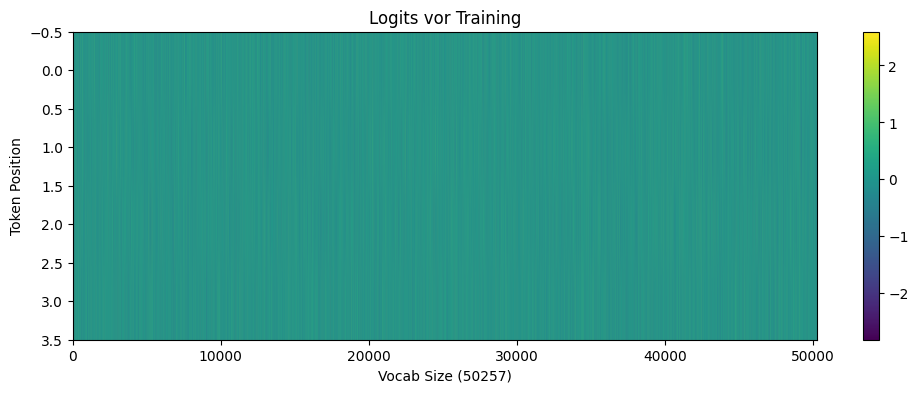

In [154]:
encoded_tensor = torch.tensor(
    tokenizer.encode("Recepie:")).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output_vor = model(encoded_tensor)
model.train()

plt.figure(figsize=(12, 4))
plt.imshow(output_vor[0].cpu().detach().numpy(), aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Logits vor Training")
plt.xlabel("Vocab Size (50257)")
plt.ylabel("Token Position")
plt.show()

# Hilfsfunktionen zur Textkonvertierung

text_to_token_ids kodiert einen Text mittels tiktoken in Token IDs 
und fügt eine Batch-Dimension hinzu, da das Modell einen 2D Tensor 
als Eingabe erwartet.

token_ids_to_text dekodiert Token IDs zurück in lesbaren Text 
indem die Batch-Dimension entfernt und die IDs mittels tiktoken 
in Zeichenketten umgewandelt werden.

In [21]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())

# Evaluierungs- und Sampling Funktionen

evaluate_model berechnet den Loss auf Trainings- und Validierungsdaten 
während des Trainings. Das Modell wird dabei in den Evaluierungsmodus 
versetzt um Dropout zu deaktivieren, und anschließend wieder in den 
Trainingsmodus zurückgesetzt.

generate_and_print_sample generiert nach jeder Trainingsepoche einen 
Beispieltext um den Lernfortschritt des Modells qualitativ zu beurteilen. 
Der generierte Text zeigt wie gut das Modell bereits sinnvolle 
Rezeptstrukturen erlernt hat.

In [22]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50, temperature=0.8, top_k=25):
    model.eval()
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=text_to_token_ids(start_context, tokenizer).to(device),
            max_new_tokens=max_new_tokens,
            context_size=model.pos_emb.weight.shape[0],
            temperature=temperature,   
            top_k=top_k,
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


# Live Visualisierung des Trainingsverlaufs

Der Live Plot aktualisiert sich nach jedem Evaluierungsschritt während 
des Trainings und zeigt den Verlauf von Training Loss und Validation Loss. 
clear_output löscht dabei die vorherige Ausgabe um eine animierte 
Darstellung zu erzeugen. So kann der Lernfortschritt des Modells in 
Echtzeit beobachtet werden und ein frühzeitiges Overfitting erkannt werden.


In [23]:

from IPython.display import clear_output
import matplotlib.pyplot as plt

def plot_losses_live(train_losses, val_losses, tokens_seen):
    clear_output(wait=True)
    clear_output(wait=True)
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss")
    ax1.legend()
    plt.tight_layout()
    plt.show()
    


In [158]:
# Vor Training
print("Vor dem Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Vor dem Training
Recepie: grandparentsintageBrend Responseidently AngelsSL Command Block pondsps tablespoonsitelyasking abolition android bullish thirds 371 Adrian


# Training

Implementierung der Trainingsschleife mittels train_model_simple. 
In jeder Iteration wird der Loss berechnet, die Gradienten durch 
loss.backward() propagiert und die Gewichte durch den AdamW Optimizer 
aktualisiert. AdamW wird gegenüber dem klassischen SGD bevorzugt da 
er adaptive Lernraten verwendet und Weight Decay zur Regularisierung 
integriert.

Alle eval_freq Schritte wird der aktuelle Loss auf Trainings- und 
Validierungsdaten berechnet und der Live Plot aktualisiert. Nach jeder 
Epoche wird ein Beispieltext generiert um den qualitativen Lernfortschritt 
zu beurteilen.

## Overfitting Analyse

Nach dem Training wird überprüft ob der Validation Loss am Ende höher 
ist als zu Beginn. Ein steigender Validation Loss bei sinkendem Training 
Loss deutet auf Overfitting hin, das Modell hat die Trainingsdaten 
auswendig gelernt anstatt allgemeine Sprachmuster zu erkennen. Bei einem 
kleinen Datensatz wie hier ist Overfitting ein erwartetes Verhalten.

Vor dem Training
Recepie:abethnin divineALL ruin Functional habit assigned missing Near Nancy-(busters Presidents patriot foldmentioned remote Claudia Minotaur


Epoche 1/7:   0%|          | 0/5912 [00:00<?, ?it/s]

Ep 1 (Step 0): Train 8.830 | Val 8.827
Ep 1 (Step 500): Train 2.534 | Val 2.521
Ep 1 (Step 1000): Train 2.221 | Val 2.232
Ep 1 (Step 1500): Train 2.003 | Val 2.083
Ep 1 (Step 2000): Train 1.890 | Val 1.982
Ep 1 (Step 2500): Train 1.891 | Val 1.911
Ep 1 (Step 3000): Train 1.823 | Val 1.855
Ep 1 (Step 3500): Train 1.766 | Val 1.813
Ep 1 (Step 4000): Train 1.691 | Val 1.774
Ep 1 (Step 4500): Train 1.688 | Val 1.753
Ep 1 (Step 5000): Train 1.670 | Val 1.724
Ep 1 (Step 5500): Train 1.624 | Val 1.700
Recipe: Pineapple Pudding Cake Mix Ingredients: 1 box Duncan Hines Butter Recipe supreme cake mix 1 box instant vanilla pudding mix 1 box instant vanilla pudding 3 c. milk 1 large Cool Whip 3 large eggs 1 (


Epoche 2/7:   0%|          | 0/5912 [00:00<?, ?it/s]

Ep 2 (Step 6000): Train 1.544 | Val 1.680
Ep 2 (Step 6500): Train 1.564 | Val 1.665
Ep 2 (Step 7000): Train 1.591 | Val 1.657
Ep 2 (Step 7500): Train 1.574 | Val 1.639
Ep 2 (Step 8000): Train 1.541 | Val 1.624
Ep 2 (Step 8500): Train 1.488 | Val 1.617
Ep 2 (Step 9000): Train 1.516 | Val 1.610
Ep 2 (Step 9500): Train 1.464 | Val 1.594
Ep 2 (Step 10000): Train 1.411 | Val 1.584
Ep 2 (Step 10500): Train 1.451 | Val 1.576
Ep 2 (Step 11000): Train 1.483 | Val 1.568
Ep 2 (Step 11500): Train 1.416 | Val 1.563
Recipe: Chocolate Chip Cookies Ingredients: 2 1/4 c. flour 1 Tbsp. baking powder 1 tsp. salt 1 1/2 c. shortening 1 c. sugar 2 eggs 1/2 c. milk


...

Ep 5 (Step 24000): Train 1.307 | Val 1.486
Ep 5 (Step 24500): Train 1.291 | Val 1.485
Ep 5 (Step 25000): Train 1.282 | Val 1.476
Ep 5 (Step 25500): Train 1.297 | Val 1.477
Ep 5 (Step 26000): Train 1.279 | Val 1.478
Ep 5 (Step 26500): Train 1.258 | Val 1.475
Ep 5 (Step 27000): Train 1.293 | Val 1.474
Ep 5 (Step 27500): Train 1.233 | Val 1.471
Ep 5 (Step 28000): Train 1.229 | Val 1.465
Ep 5 (Step 28500): Train 1.244 | Val 1.463
Ep 5 (Step 29000): Train 1.258 | Val 1.464
Ep 5 (Step 29500): Train 1.269 | Val 1.458
Recipe: Cabbage And Apple Salad Ingredients: 1 head cabbage 1 red apple 1/2 apple 2 apples 1 cucumber 1 head cabbage 1 small bottle mayonnaise Directions: Cook cabbage until tender. 


Epoche 6/7:   0%|          | 0/5912 [00:00<?, ?it/s]

Ep 6 (Step 30000): Train 1.236 | Val 1.472
Ep 6 (Step 30500): Train 1.232 | Val 1.473
Ep 6 (Step 31000): Train 1.304 | Val 1.473
Ep 6 (Step 31500): Train 1.216 | Val 1.467
Ep 6 (Step 32000): Train 1.177 | Val 1.466
Ep 6 (Step 32500): Train 1.209 | Val 1.458
Ep 6 (Step 33000): Train 1.185 | Val 1.457
Ep 6 (Step 33500): Train 1.188 | Val 1.458
Ep 6 (Step 34000): Train 1.203 | Val 1.451
Ep 6 (Step 34500): Train 1.248 | Val 1.447
Ep 6 (Step 35000): Train 1.209 | Val 1.445
Recipe: Chocolate Pie Ingredients: 1 c. white sugar 2 Tbsp. cocoa 1 Tbsp. cornstarch 1/2 tsp. salt 2 Tbsp. cornstarch 3 Tbsp. cocoa 2 c.


Epoche 7/7:   0%|          | 0/5912 [00:00<?, ?it/s]

Ep 7 (Step 35500): Train 1.171 | Val 1.455
Ep 7 (Step 36000): Train 1.164 | Val 1.463
Ep 7 (Step 36500): Train 1.198 | Val 1.464
Ep 7 (Step 37000): Train 1.231 | Val 1.464
Ep 7 (Step 37500): Train 1.210 | Val 1.457
Ep 7 (Step 38000): Train 1.164 | Val 1.459
Ep 7 (Step 38500): Train 1.166 | Val 1.453
Ep 7 (Step 39000): Train 1.184 | Val 1.451
Ep 7 (Step 39500): Train 1.178 | Val 1.456
Ep 7 (Step 40000): Train 1.190 | Val 1.450
Ep 7 (Step 40500): Train 1.209 | Val 1.445
Ep 7 (Step 41000): Train 1.198 | Val 1.447
Recipe: No-Bake Cookies Ingredients: 1/4 c. cocoa 1/2 c. milk 1/4 c. peanut butter 1 tsp. vanilla 2 c. quick oats Directions: Mix together cocoa,

Bestes Modell wiederhergestellt (Val-Loss 1.445).
Nach Training
Recepie:
Ingredients:
1 (9-inch) unbaked pastry shell
1 (6 oz.)


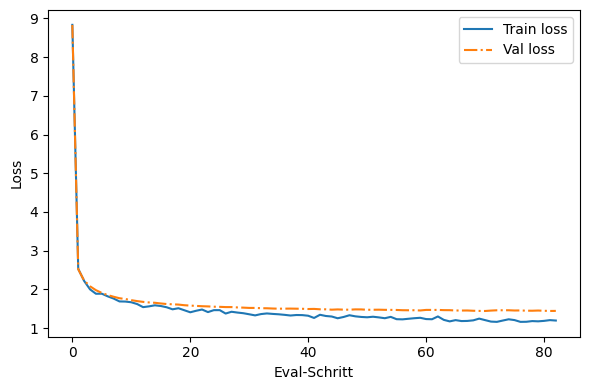

Val-Loss-Minimum: 1.445 | am Ende: 1.447 → Overfitting nach dem Tiefpunkt


In [24]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    best_val_loss = float("inf")          # Early Stopping
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in tqdm(train_loader, desc=f"Epoche {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # Grad-Clipping
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                tqdm.write(f"Ep {epoch+1} (Step {global_step}): Train {train_loss:.3f} | Val {val_loss:.3f}")

                if val_loss < best_val_loss:                                    # Early Stopping: bestes Modell merken
                    best_val_loss = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        generate_and_print_sample(model, tokenizer, device, start_context)

    if best_state is not None:                                                  # bestes statt letztes Modell behalten
        model.load_state_dict(best_state)
        print(f"\nBestes Modell wiederhergestellt (Val-Loss {best_val_loss:.3f}).")
    return train_losses, val_losses, track_tokens_seen


tokenizer = tiktoken.get_encoding("gpt2")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

# Vor Training
print("Vor dem Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

num_epochs = 7
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=500, eval_iter=20,
    start_context="Recipe:", tokenizer=tokenizer
)
# Nach Training
print("Nach Training")
torch.manual_seed(123)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Recepie:", tokenizer).to(device),
    max_new_tokens=20,
    context_size=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

# Plot einmal am Ende (ohne clear_output -> Log + Plot bleiben sichtbar)
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, linestyle="-.", label="Val loss")
plt.xlabel("Eval-Schritt"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

# Overfitting-Report
if val_losses[-1] > min(val_losses):
    print(f"Val-Loss-Minimum: {min(val_losses):.3f} | am Ende: {val_losses[-1]:.3f} → Overfitting nach dem Tiefpunkt")
else:
    print("Val-Loss noch fallend — evtl. mehr Daten/Epochen möglich")

# Loss Verlauf

Der Plot zeigt den vollständigen Trainingsverlauf von Beginn bis Ende.
Der Training Loss sinkt kontinuierlich was zeigt dass das Modell die 
Rezeptstruktur schrittweise erlernt. Der Validation Loss gibt Aufschluss 
darüber ob das Modell generalisiert oder die Trainingsdaten auswendig lernt.
Ein steigender Validation Loss bei sinkendem Training Loss deutet auf 
Overfitting hin.

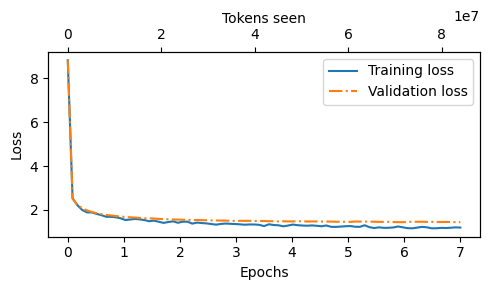

In [25]:
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

# Quantitative Bewertung des Trainingserfolgs

Der initiale Loss von ln(50257) ≈ 10.82 entspricht einem Modell das 
gleichmäßig über alle Tokens rät. Nach dem Training lässt sich der 
Lernfortschritt mathematisch quantifizieren. Die Reduktion gibt an 
um wie viel Prozent der Loss gesunken ist, der Verbesserungsfaktor 
zeigt wie viel wahrscheinlicher das Modell das richtige Token nach 
dem Training im Vergleich zu zufälligem Raten vorhersagt.

In [161]:

import math

loss_initial = math.log(50257)  
loss_after   = train_losses[-1]

reduktion = (loss_initial - loss_after) /  loss_initial *   100

verbesserung = math.exp(-loss_after) / math.exp(-loss_initial)

print(f"Initialer Loss: {loss_initial:.2f}")
print(f"Loss nach Training:{loss_after:.2f}")
print(f"Reduktion:  {reduktion:.1f}%")
print(f"Verbesserung: Faktor {verbesserung:.0f}x")

Initialer Loss: 10.82
Loss nach Training:2.38
Reduktion:  78.0%
Verbesserung: Faktor 4649x


# Logits nach Training

Nach dem Training zeigt die Heatmap deutlich erkennbare Muster.
Bestimmte Token Positionen weisen nun stark erhöhte Scores für
spezifische Tokens auf ; das Modell hat gelernt welche Tokens
in einem Rezeptkontext wahrscheinlich folgen. 

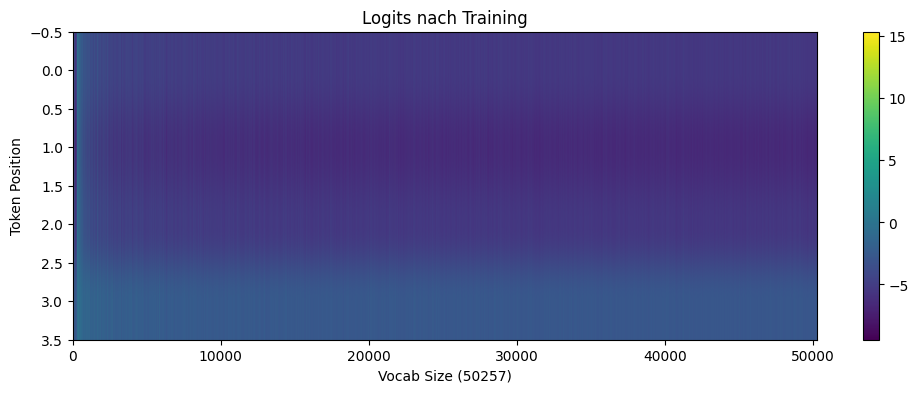

In [162]:
model.eval()
with torch.no_grad():
    output_nach = model(encoded_tensor)
model.train()

plt.figure(figsize=(12, 4))
plt.imshow(output_nach[0].cpu().detach().numpy(), aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Logits nach Training")
plt.xlabel("Vocab Size (50257)")
plt.ylabel("Token Position")
plt.show()

# Erweiterte Textgenerierung

Implementierung der generate Funktion als Erweiterung von 
generate_text_simple mit zwei zusätzlichen Dekodierungsstrategien.

## Top-k Sampling

Top-k Sampling beschränkt die Auswahl des nächsten Tokens auf die 
k wahrscheinlichsten Kandidaten. Alle anderen Tokens werden auf 
-inf gesetzt und nach der Softmax-Funktion zu 0. Dies verhindert 
dass unwahrscheinliche Tokens ausgewählt werden.

## Temperature Scaling

Temperature skaliert die Logits vor der Softmax-Funktion. Eine niedrige 
Temperature macht die Verteilung schärfer und das Modell wählt 
konservativer das wahrscheinlichste Token. Eine hohe Temperature 
verteilt die Wahrscheinlichkeiten gleichmäßiger und erzeugt 
kreativeren aber weniger kohärenten Text. Bei temperature=0.0 
wird Greedy Decoding verwendet wie in generate_text_simple.

In [26]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# Vergleich verschiedener Temperaturen

Der Vergleich zeigt den Einfluss der Temperature auf den generierten Text. 
Bei temperature=0.0 wird stets das wahrscheinlichste Token gewählt, 
was zu deterministischem aber repetitivem Text führt. Mit steigender 
Temperature wird die Ausgabe zunehmend variabler und kreativer, 
jedoch auf Kosten der sprachlichen Kohärenz. temperature=1.4 erzeugt 
den kreativsten Text, kann jedoch auch zu weniger sinnvollen 
Wortfolgen führen.

In [27]:
temperatures = [0.0, 0.5, 1.4]

for temp in temperatures:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids("Recipe:", tokenizer).to(device),
        max_new_tokens=20,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=temp
    )
    print(temp)
    print(token_ids_to_text(token_ids, tokenizer))

0.0
Recipe: Chicken And Rice
Ingredients:
1/2 c. uncooked rice
1/4 c
0.5
Recipe: Easy Beef Stroganoff
Ingredients:
1 lb. ground beef
1 can cream of mushroom
1.4
Recipe: Easy Beef Tips
Ingredients:
1 large jar of onion soup (any brand)
1 beef


# Generierung verschiedener Rezepte

Das trainierte Modell wird mit verschiedenen Rezeptanfängen getestet 
um die Generalisierungsfähigkeit zu evaluieren. Jeder Kontext gibt 
einen Rezepttitel und den Beginn der Zutatenliste vor, woraufhin 
das Modell die Fortsetzung generiert.

Da das Modell auf Rezeptdaten trainiert wurde, sollte es grundlegende 
Rezeptstrukturen wie Zutatenmengen und Zubereitungsschritte erkennen. 
Die Qualität der generierten Rezepte hängt dabei direkt von der 
Trainingsdatenmenge und der Anzahl der Trainingsepochen ab. Bei einem 
kleinen Datensatz und wenigen Epochen sind die Ausgaben noch 
inkohärent, zeigen jedoch bereits grundlegende Rezeptmuster.

In [28]:
contexts = [
    "Recipe: Chocolate Cake\nIngredients:",
    "Recipe: Pizza\nIngredients:",
    "Recipe: Soup\nIngredients:",
]

for context in contexts:
    torch.manual_seed(123)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(context, tokenizer).to(device),
        max_new_tokens=100,
        context_size=GPT_CONFIG["context_length"],
        top_k=25,
        temperature=1.4
    )
    print(f"\nStart: {context}")
    print(f"Generated: {token_ids_to_text(token_ids, tokenizer)}")


Start: Recipe: Chocolate Cake
Ingredients:
Generated: Recipe: Chocolate Cake
Ingredients:
2 3/4 c. all-purpose flour
4 (3/4 oz.) sqweetened chocolate, grated
4/3 c. sweet butter, softened
1 3/4 c. sugar
4 eggs or 3/4 c. plain yogurt
1 tsp. ground nutmeg
1/4 c. evaporated milk
Directions:
Sift flour and baking squares 1/2 of sugar and set aside on waxed paper and waxed paper. Pre

Start: Recipe: Pizza
Ingredients:
Generated: Recipe: Pizza
Ingredients:
7 3/4 oz. pizza crumbled corn tortilla chips (about 6 oz.)
1/4 c. pizza sauce
dash of garlic powder (fresh)
1/4 c. diced Cheddar cheese
Directions:
Place 2 tablespoons of the vegetable filling in a small mixing bowl.
Heat.
Spread each in a spoon of pizza pan. Bake at 450°, about 5 minutes, until mixture is puffy on each side. Serve on a hot plate.

Start: Recipe: Soup
Ingredients:
Generated: Recipe: Soup
Ingredients:
7 large potatoes, cut in small pieces
1/4 cup onion, minced
1 cup celery, minced (6 c.)
1/4 cup fresh parsley, shredded
4 t

# Textgenerierung mit optimierten Parametern

Abschließende Textgenerierung mit den optimierten Dekodierungsparametern 
top_k=25 und temperature=1.4. Diese Kombination aus Top-k Sampling 
und Temperature Scaling erzeugt einen ausgewogenen Text der sowohl 
kohärent als auch kreativ ist. Der generierte Text zeigt den 
aktuellen Lernstand des Modells nach dem Training auf dem Rezeptdatensatz.

In [29]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recipe:", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Recipe: Easy Beef Tips
Ingredients:
1 large jar of onion soup (any


In [30]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
best_val = min(val_losses)
RUN_NAME = f"model_pretrained_r{len(recipes)}_ctx{GPT_CONFIG['context_length']}_e{num_epochs}_val{best_val:.2f}_{ts}"
MODEL_PATH = f"datasets/pre-training/{RUN_NAME}.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "num_epochs": num_epochs,
}, MODEL_PATH)
print(f"Modell gespeichert: {MODEL_PATH}")


Modell gespeichert: datasets/pre-training/model_pretrained_r100000_ctx512_e7_val1.44_20260616_074303.pth


## OpenAI-GPT-2-Gewichte laden & vergleichen

#### 1) Gewichte herunterladen & ins Modell laden
download_and_load_gpt2 lädt den offiziellen GPT-2-Checkpoint (TensorFlow-Format)
von OpenAI und gibt settings (Hyperparameter) + params (Gewichts-Arrays) zurück.
load_weights_into_gpt kopiert diese Arrays Position für Position in unsere
eigene GPTModel-Instanz (Embeddings → jeder Transformer-Block → finale Norm → Output-Head).

Die Config muss exakt zu GPT-2-small passen, sonst Shape-Mismatch:
-  qkv_bias=True -> GPT-2 nutzt Bias in der Attention; fehlen diese Parameter, schlägt das Zuweisen fehl.
- context_length=1024 -> GPT-2s Positions-Embedding ist [1024, 768]; mit 256 → Shape-Fehler.
- drop_rate=0.0 -> wir evaluieren nur, kein Dropout nötig.

In [31]:
from gpt_download import download_and_load_gpt2

# Lädt den GPT-2-small-Checkpoint (124M) — gleiche Architektur wie unser Modell
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

# Config exakt nach GPT-2-small (Abweichungen zum Trainingsmodell markiert)
GPT2_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,   # GPT-2: 1024 (nicht 256!) — sonst Shape-Mismatch bei pos_emb
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,         # nur Eval
    "qkv_bias": True,         # GPT-2 hat Attention-Bias -> MUSS True sein
}

gpt2 = GPTModel(GPT2_CONFIG)
load_weights_into_gpt(gpt2, params)   # OpenAI-Gewichte in unsere Architektur kopieren
gpt2.to(device)
gpt2.eval()
print("GPT-2 (124M) geladen.")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
GPT-2 (124M) geladen.


#### 2) Train-/Validierungs-Loss auf unseren Rezeptdaten
Wir nutzen  exakt dieselbe calc_loss_loader-Funktion und dieselben
train_loader/val_loader wie für unser eigenes Modell, nur das Modell ist
ausgetauscht. Dadurch sind die Loss-Werte direkt vergleichbar.
(Unsere Loader liefern 256-Token-Sequenzen; GPT-2 verträgt bis 1024 → passt.)

**Erwartung:** GPT-2 hat unsere Rezepte nie gesehen, ist aber auf riesigen
Textmengen trainiert → sein Loss sollte deutlich niedriger liegen als der
unseres From-Scratch-Modells. 

In [32]:
torch.manual_seed(123)
with torch.no_grad():
    gpt2_train_loss = calc_loss_loader(train_loader, gpt2, device, num_batches=20)
    gpt2_val_loss   = calc_loss_loader(val_loader,   gpt2, device, num_batches=20)

print("=== Loss-Vergleich auf unseren Rezeptdaten ===")
print(f"From-Scratch ({len(recipes)}   -> Train: {train_losses[-1]:.3f} | Val: {val_losses[-1]:.3f}")
print(f"GPT-2 OpenAI (124M, Web-Text) -> Train: {gpt2_train_loss:.3f} | Val: {gpt2_val_loss:.3f}")

=== Loss-Vergleich auf unseren Rezeptdaten ===
From-Scratch (100000   -> Train: 1.198 | Val: 1.447
GPT-2 OpenAI (124M, Web-Text) -> Train: 2.521 | Val: 2.538


# Textvergleich: From-Scratch vs OpenAI GPT-2

Beide Modelle erhalten den gleichen Startkontext und generieren 50 neue Tokens 
mit identischen Parametern. Das From-Scratch Modell wurde nur auf 200 Rezepten 
für eine Epoche trainiert während GPT-2 von OpenAI auf Milliarden Texten aus 
dem Internet vortrainiert wurde. Der Vergleich zeigt deutlich den Unterschied 
zwischen einem minimalen eigenen Training und einem professionell vortrainierten 
Sprachmodell.

Textvergleich
Unser Modell:
Recepie: Chocolate Cake
Ingredients:
2 3/4 c. all-purpose flour
1 1/2 c. sugar
1/4 c. cocoa
1/2 tsp. baking soda
1 3/4 tsp. baking powder
1/4 tsp. salt

OpenAI GPT-2:
Recepie: Chocolate Cake
Ingredients:
For the filling:
Creamy almond milk, 2 tbsp. cold water, 1 tsp. vanilla extract
Directions:
For the buttercream icing:
Use 2 tbsp. of buttercream icing mix (I use 1 tbsp.


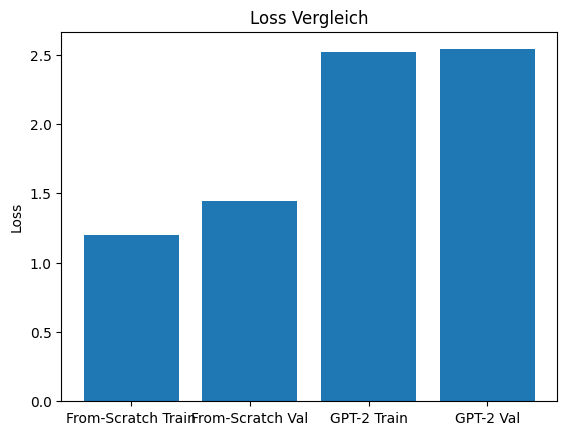

In [33]:
print("Textvergleich")
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
print("Unser Modell:")
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Recepie: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=50,
    context_size=GPT_CONFIG["context_length"],
    top_k=25,
    temperature=1.0
)
print(token_ids_to_text(token_ids, tokenizer))

print("\nOpenAI GPT-2:")
torch.manual_seed(123)
token_ids = generate(
    model=gpt2,
    idx=text_to_token_ids("Recepie: Chocolate Cake\nIngredients:", tokenizer).to(device),
    max_new_tokens=50,
    context_size=GPT2_CONFIG["context_length"],
    top_k=25,
    temperature=1.0,
    eos_id=eot_id
)
print(token_ids_to_text(token_ids, tokenizer))

plt.bar(["From-Scratch Train", "From-Scratch Val", "GPT-2 Train", "GPT-2 Val"],
        [train_losses[-1], val_losses[-1], gpt2_train_loss, gpt2_val_loss])
plt.ylabel("Loss")
plt.title("Loss Vergleich")
plt.show()

#### 3) Textgenerierung
Wir rufen dieselbe generate()-Funktion (Top-k + Temperature) auf wie oben,
nur mit gpt2 als Modell. eos_id setzen wir auf das `<|endoftext|>`-Token,
damit die Generierung am Dokumentende stoppen kann.

In [34]:
eot_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]

for context in ["Recipe: Chocolate Cake\nIngredients:", "Recipe: Pizza\nIngredients:"]:
    torch.manual_seed(123)
    token_ids = generate(
        model=gpt2,
        idx=text_to_token_ids(context, tokenizer).to(device),
        max_new_tokens=100,
        context_size=GPT2_CONFIG["context_length"],
        top_k=25,
        temperature=1.0,
        eos_id=eot_id,
    )
    print(f"\nStart: {context}")
    print(f"Generated: {token_ids_to_text(token_ids, tokenizer)}")


Start: Recipe: Chocolate Cake
Ingredients:
Generated: Recipe: Chocolate Cake
Ingredients: 1/2 oz. of chocolate, melted
¼ cup plus 1/4 cup of coconut milk or milk of choice, chopped
Cake flour or egg powder: optional
For topping: 1 tbsp of coconut flour
1/2 tsp of baking powder: optional (please include a note on the colourings and textures on the cake if it is brown in color)
For topping, add 1 or more tbsp of maple syrup and 1/4 tsp of salt
For baking: 1

Start: Recipe: Pizza
Ingredients:
Generated: Recipe: Pizza
Ingredients:
1/2 cup of olive oil
1 tablespoon of salt
1 teaspoon of ground nutmeg
Fresh chopped parsley, chopped
Cheddar cheese, grated
Cream cheese, grated
Sliced celery, chopped into 3 pieces to coat evenly (you want a big amount)
1/2 cup of tomato paste
Mince butter to your liking.
Place the cheese in a large skillet, and stir to mix with a fork.
While the heat is
